## EDA vs Data Cleaning ##

## 1. Import Libraries ##

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import emoji

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
%matplotlib inline

## 2. Load Dataset ##

In [2]:
# Load dataset
file_path = "C:/Users/HOAI HUE/Desktop/tiki/data/raw/tiki_reviews.csv"

df = pd.read_csv(file_path)

# Display the first few rows
display(df.head())

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

,review_id,product_id,category_id,customer_id,customer_name,rating,title,content,created_at_ts,created_at_date,purchased_at_ts,purchased_at_date,days_since_purchase,helpful_count,is_verified,images_count
0,20205835,278631185,2552,1166119.0,Mai Thị Lan Anh,5,Cực kì hài lòng,NaN,1768406964,1/14/2026,1.766720e+09,12/26/2025,19.0,0,True,0
1,20181960,278631185,2552,29087580.0,Mai Ngọc Mi,5,Cực kì hài lòng,NaN,1760546795,10/15/2025,1.759378e+09,10/2/2025,13.0,0,True,0
2,20193648,277775605,2552,12179128.0,Ngan Logistic Nguyen Huy Thanh,5,Cực kì hài lòng,NaN,1764219890,11/27/2025,1.762999e+09,11/13/2025,14.0,0,True,0
3,20192566,277725874,2552,6735966.0,Lê Nguyễn Thùy Linh,5,Cực kì hài lòng,Mình mua được giá tốt,1763803857,11/22/2025,1.763954e+09,11/24/2025,-1.0,0,True,1
4,19946607,274756690,2552,29498187.0,Lê Ngọc Hải,5,Cực kì hài lòng,NaN,1722934258,8/6/2024,1.722857e+09,8/5/2024,0.0,0,True,0


Dataset shape: (74036, 16)
Number of rows: 74036
Number of columns: 16


# 3. Kiểm tra thông tin dataset

In [3]:
print("Data types:")
print(df.dtypes)

print("\nSummary statistics:")
display(df.describe(include="all"))

Data types:
review_id                int64
product_id               int64
category_id              int64
customer_id            float64
customer_name              str
rating                   int64
title                      str
content                    str
created_at_ts            int64
created_at_date            str
purchased_at_ts        float64
purchased_at_date          str
days_since_purchase    float64
helpful_count            int64
is_verified               bool
images_count             int64
dtype: object

Summary statistics:


,review_id,product_id,category_id,customer_id,customer_name,rating,title,content,created_at_ts,created_at_date,purchased_at_ts,purchased_at_date,days_since_purchase,helpful_count,is_verified,images_count
count,7.403600e+04,7.403600e+04,74036.000000,7.394800e+04,73964,74036.000000,74036,28185,7.403600e+04,74036,7.386000e+04,73860,73860.000000,74036.000000,74036,74036.000000
unique,NaN,NaN,NaN,NaN,38417,NaN,1458,21708,NaN,3043,NaN,3066,NaN,NaN,2,NaN
top,NaN,NaN,NaN,NaN,Tài khoản Zalo,NaN,Cực kì hài lòng,ok,NaN,12/12/2021,NaN,12/12/2021,NaN,NaN,True,NaN
freq,NaN,NaN,NaN,NaN,135,NaN,61676,760,NaN,242,NaN,777,NaN,NaN,73860,NaN
mean,1.223346e+07,5.969671e+07,5266.756753,1.188349e+07,NaN,4.754052,NaN,NaN,1.637973e+09,NaN,1.635997e+09,NaN,24.553155,0.113053,NaN,0.160381
std,5.278351e+06,7.111394e+07,8258.878814,7.841324e+06,NaN,0.730548,NaN,NaN,3.976375e+07,NaN,4.024549e+07,NaN,61.954414,2.743150,NaN,0.510068
min,1.350040e+05,1.341460e+05,2552.000000,3.800000e+01,NaN,1.000000,NaN,NaN,1.415783e+09,NaN,1.420437e+09,NaN,-1335.000000,0.000000,NaN,0.000000
25%,7.893494e+06,3.015787e+06,2555.000000,6.335740e+06,NaN,5.000000,NaN,NaN,1.613967e+09,NaN,1.611930e+09,NaN,3.000000,0.000000,NaN,0.000000
50%,1.282143e+07,3.469782e+07,2567.000000,1.127258e+07,NaN,5.000000,NaN,NaN,1.635147e+09,NaN,1.633752e+09,NaN,10.000000,0.000000,NaN,0.000000
75%,1.648720e+07,8.040385e+07,2606.000000,1.767040e+07,NaN,5.000000,NaN,NaN,1.653702e+09,NaN,1.652103e+09,NaN,31.000000,0.000000,NaN,0.000000


# 4. Kiểm tra missing values #

In [3]:
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
review_id                  0
product_id                 0
category_id                0
customer_id               88
customer_name             72
rating                     0
title                      0
content                45851
created_at_ts              0
created_at_date            0
purchased_at_ts          176
purchased_at_date        176
days_since_purchase      176
helpful_count              0
is_verified                0
images_count               0
dtype: int64


## 5. Giữ các cột cần thiết cho bài toán ABSA + Recommend system ##

In [4]:
columns_needed = [
    'review_id',
    'product_id',
    'customer_id',
    'rating',
    'content',
    'title'
]

df = df[columns_needed]

print("New dataset shape:", df.shape)
display(df.head())

New dataset shape: (74036, 6)


,review_id,product_id,customer_id,rating,content,title
0,20205835,278631185,1166119.0,5,NaN,Cực kì hài lòng
1,20181960,278631185,29087580.0,5,NaN,Cực kì hài lòng
2,20193648,277775605,12179128.0,5,NaN,Cực kì hài lòng
3,20192566,277725874,6735966.0,5,Mình mua được giá tốt,Cực kì hài lòng
4,19946607,274756690,29498187.0,5,NaN,Cực kì hài lòng


## 6. Xóa dữ liệu trống không quan trọng ##

In [5]:
rows_before = df.shape[0]
df = df.dropna(subset=["content", "rating"])
rows_after = df.shape[0]
print(f"Removed {rows_before - rows_after} rows with missing review text or rating")

Removed 45851 rows with missing review text or rating


# 7. Xóa duplicate review #

In [6]:
# Check for duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Drop duplicates
rows_before = df.shape[0]
df.drop_duplicates(inplace=True)
rows_after = df.shape[0]
print(f"Removed {rows_before - rows_after} duplicate rows")

# Verify no duplicates remain
print(f"Duplicates after removal: {df.duplicated().sum()}")

Number of duplicate rows: 1
Removed 1 duplicate rows
Duplicates after removal: 0


In [8]:
df.shape

(28184, 6)

In [ ]:

df.head()

,review_id,product_id,customer_id,rating,content,title
3,20192566,277725874,6735966.0,5,Mình mua được giá tốt,Cực kì hài lòng
8,20177015,274756685,21207764.0,5,CHẤT liệu ok bé dùng rất thoải mái,Cực kì hài lòng
10,19944121,274756681,17631273.0,5,"Giao hàng nhanh hơn dự kiến, sp phù hợp túi tiền",Cực kì hài lòng
12,20159090,274756679,28349168.0,5,Đã dùng và rất thích rất êm rất thích hok bị h...,Cực kì hài lòng
16,19899584,274091857,6970204.0,5,Sản phẩm tuyệt vời tư vấn nhiệt tình,Cực kì hài lòng


# 8. EDA – Phân bố rating #

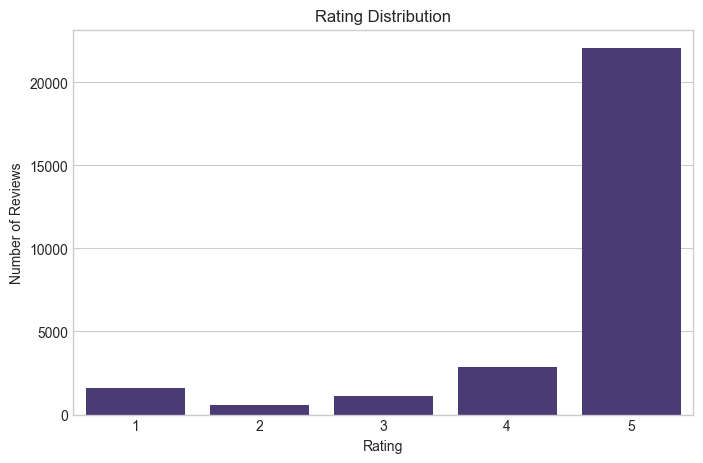

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(x="rating", data=df)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

Biểu đồ cho thấy một sự lệch trái cực lớn, trong đó xếp hạng 5 sao chiếm số lượng áp đảo với hơn 20.000 lượt đánh giá.

In [10]:
df.head()

,review_id,product_id,customer_id,rating,content,title
3,20192566,277725874,6735966.0,5,Mình mua được giá tốt,Cực kì hài lòng
8,20177015,274756685,21207764.0,5,CHẤT liệu ok bé dùng rất thoải mái,Cực kì hài lòng
10,19944121,274756681,17631273.0,5,"Giao hàng nhanh hơn dự kiến, sp phù hợp túi tiền",Cực kì hài lòng
12,20159090,274756679,28349168.0,5,Đã dùng và rất thích rất êm rất thích hok bị h...,Cực kì hài lòng
16,19899584,274091857,6970204.0,5,Sản phẩm tuyệt vời tư vấn nhiệt tình,Cực kì hài lòng


# 9. EDA – Độ dài review #

Statistics for 'content' column:
count     28184
unique    21708
top          ok
freq        759
Name: content, dtype: object


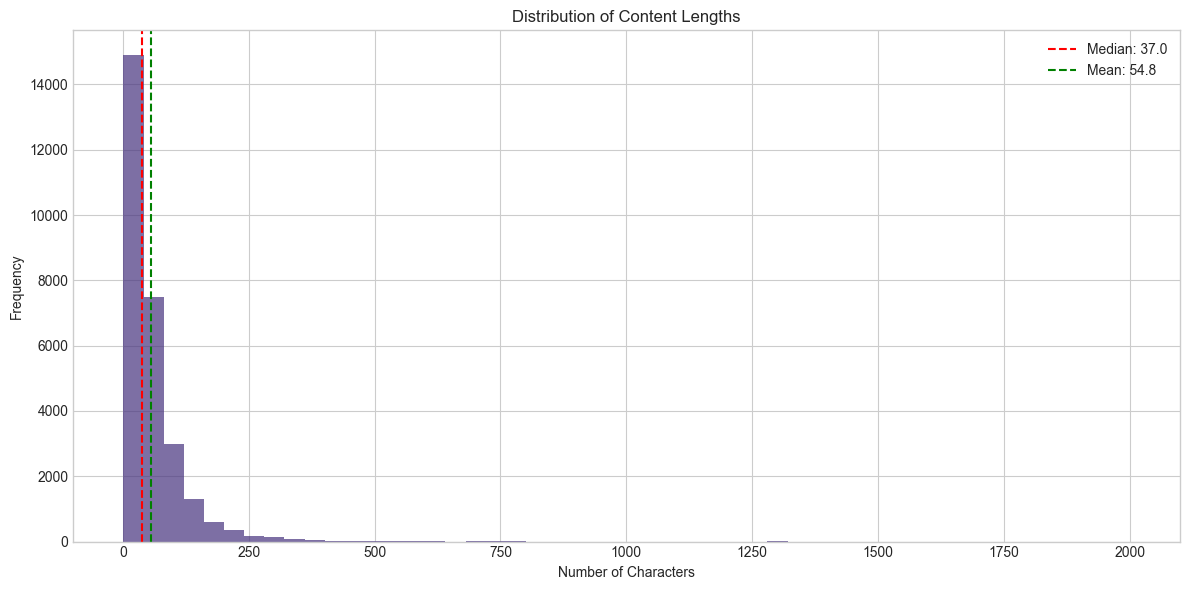

In [11]:
# Check statistics for 'content' column
content_stats = df['content'].describe()
print("Statistics for 'content' column:")
print(content_stats)

# Check content length distribution
content_lengths = df['content'].str.len()
plt.figure(figsize=(12, 6))
plt.hist(content_lengths, bins=50, alpha=0.7)
plt.axvline(content_lengths.median(), color='red', linestyle='--', label=f'Median: {content_lengths.median()}')
plt.axvline(content_lengths.mean(), color='green', linestyle='--', label=f'Mean: {content_lengths.mean():.1f}')
plt.title('Distribution of Content Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

Phân bố độ dài bị lệch về bên phải, với phần lớn các đánh giá ngắn.
Ngoài ra, có nhiều đánh giá bị trùng lặp và nhiều đánh giá chứa nội dung ngắn như "ok", điều này hạn chế tính hữu ích của chúng đối với các tác vụ xử lý ngôn ngữ tự nhiên và hệ thống đề xuất.

Xóa hàng có nội dung trung lặp

In [12]:
# Check duplicates in 'content' column
content_duplicates = df['content'].duplicated().sum()
print(f"Number of duplicate contents: {content_duplicates}")

# Drop duplicates in 'content' column
rows_before = df.shape[0]
df.drop_duplicates(subset=['content'], inplace=True)
rows_after = df.shape[0]
print(f"Removed {rows_before - rows_after} rows with duplicate content")

# Check duplicates in 'content' column again
print(f"Content duplicates after removal: {df['content'].duplicated().sum()}")

Number of duplicate contents: 6476
Removed 6476 rows with duplicate content
Content duplicates after removal: 0


## 10. Text Cleaning 

Loại bỏ khoảng trắng thừa, xuống dòng và các vấn đề định dạng khác khỏi cột 'nội dung'.

In [13]:
# Save some sample texts for comparison after cleaning
sample_indices = np.random.choice(df.index, 5, replace=False)
sample_texts = df.loc[sample_indices, 'content'].tolist()
print("Original sample texts:")
for i, text in enumerate(sample_texts):
    print(f"Sample {i+1}: {text[:100]}{'...' if len(text) > 100 else ''}") #cắt 100 ký tự đầu để tránh in quá dài

# Chuẩn hóa text trong cột 'content'
df['content'] = (
    df['content']
    # Xóa ký tự xuống dòng (\n)
    .str.replace('\n', ' ', regex=True)

    # Xóa ký tự carriage return (\r)
    .str.replace('\r', ' ', regex=True)

    # Gộp nhiều dấu cách liên tiếp thành 1 dấu cách
    .str.replace(' +', ' ', regex=True)

    # Xóa khoảng trắng ở đầu và cuối chuỗi
    .str.strip()
)

Original sample texts:
Sample 1: Dùng thích lắm ạ. Bé m chỉ dùng loại này thôi.
Sample 2: thấy mấy mom cứ bảo bể nên cũng thấy sợ nhưng nhận hàng thì cực kì hài lòng ghế rất đẹp tiki giao cũ...
Sample 3: ổn. rút ko đc dứt khoát 1 tờ. kiểu rút nhanh phải dính lôi ra 2 3 tờ
Sample 4: đặt hàng mà 1 tháng sau mới tới nhưng thông cảm vì do dịch bệnh. shipper dễ thương, hàng đóng gói cẩ...
Sample 5: sản phẩm giao nhanh, giá rẻ


## 11. Emoji and Special Character Processing

In [15]:
# Function to normalize repeating characters
def normalize_repeating_chars(text):
    # Kiểm tra nếu không phải kiểu string thì giữ nguyên (tránh lỗi khi xử lý dữ liệu null hoặc số)
    if not isinstance(text, str):
        return text
    
    # Replace characters that repeat more than twice with a single occurrence
    # Ví dụ: "đẹppppppp" → "đẹp", "soooo good" → "so good"
    # (.)      : bắt bất kỳ ký tự nào
    # \1{2,}   : ký tự đó lặp lại ít nhất 2 lần nữa (tổng ≥ 3 lần)
    # r'\1'    : thay thế bằng 1 ký tự duy nhất
    return re.sub(r'(.)\1{2,}', r'\1', text)


# Function to remove emojis
def remove_emojis(text):
    # Kiểm tra nếu không phải string thì giữ nguyên
    if not isinstance(text, str):
        return text
    
    # Loại bỏ toàn bộ emoji khỏi text
    # Ví dụ: "Sản phẩm tốt 😊👍" → "Sản phẩm tốt "
    return emoji.replace_emoji(text, '')

In [16]:
# Apply both processing functions to the content column
df['content'] = df['content'].apply(remove_emojis).apply(normalize_repeating_chars)

# Remove excess whitespace after processing
df['content'] = df['content'].str.replace(' +', ' ', regex=True).str.strip()

# Show samples after cleaning
print("Cleaned sample texts:")
for i, old_text in enumerate(sample_texts):
    # Find the corresponding cleaned text by matching the beginning
    idx = df[df['content'].str.contains(old_text[:min(30, len(old_text))], regex=False)].index
    if len(idx) > 0:
        new_text = df.loc[idx[0], 'content']
        print(f"Sample {i+1}: {new_text[:100]}{'...' if len(new_text) > 100 else ''}")
    else:
        print(f"Sample {i+1}: (Text not found after cleaning)")

Cleaned sample texts:
Sample 1: Dùng thích lắm ạ. Bé m chỉ dùng loại này thôi.
Sample 2: thấy mấy mom cứ bảo bể nên cũng thấy sợ nhưng nhận hàng thì cực kì hài lòng ghế rất đẹp tiki giao cũ...
Sample 3: ổn. rút ko đc dứt khoát 1 tờ. kiểu rút nhanh phải dính lôi ra 2 3 tờ
Sample 4: đặt hàng mà 1 tháng sau mới tới nhưng thông cảm vì do dịch bệnh. shipper dễ thương, hàng đóng gói cẩ...
Sample 5: sản phẩm giao nhanh, giá rẻ


In [20]:
# Verify data quality after cleaning
print("Missing values after cleaning:")
print(df.isnull().sum())

print('\nDuplicate values after emoji removal:', df.duplicated().sum())

Missing values after cleaning:
review_id       0
product_id      0
customer_id    11
rating          0
content         0
title           0
dtype: int64

Duplicate values after emoji removal: 0


In [18]:
# Remove any duplicates that may have emerged after text cleaning
rows_before = df.shape[0]
df.drop_duplicates(inplace=True)
rows_after = df.shape[0]
print(f"Removed {rows_before - rows_after} duplicate rows after text cleaning")
print(f"Final duplicate count: {df.duplicated().sum()}")

Removed 0 duplicate rows after text cleaning
Final duplicate count: 0


## 12. Content Length Analysis


Content length statistics:
Shortest content: 0 characters
Average content length: 67.41 characters
Median content length: 51.0 characters
Longest content: 1748 characters


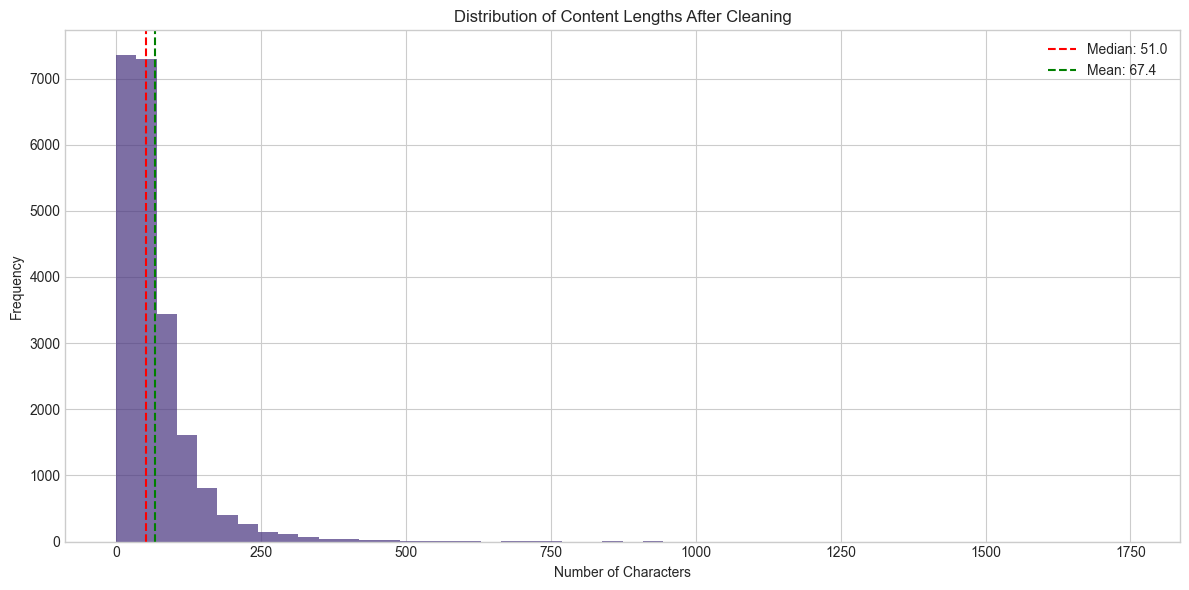


Number of very short contents (≤ 5 characters): 423

Samples of very short contents:
Row 18: 'Tốt' (Rating: 5) - Length: 3
Row 30: 'Sp ok' (Rating: 5) - Length: 5
Row 33: 'Ok' (Rating: 5) - Length: 2
Row 37: 'Ok ạ' (Rating: 5) - Length: 4
Row 60: 'tốt' (Rating: 5) - Length: 3
Row 197: 'ok' (Rating: 5) - Length: 2
Row 284: 'Ko' (Rating: 4) - Length: 2
Row 463: 'Tot' (Rating: 5) - Length: 3
Row 617: 'ổn' (Rating: 5) - Length: 2
Row 688: 'Toits' (Rating: 5) - Length: 5


In [19]:
# Analyze content length distribution
char_counts = df['content'].str.len()
print("\nContent length statistics:")
print(f"Shortest content: {char_counts.min()} characters")
print(f"Average content length: {char_counts.mean():.2f} characters")
print(f"Median content length: {char_counts.median()} characters")
print(f"Longest content: {char_counts.max()} characters")

# Visualize content length distribution
plt.figure(figsize=(12, 6))
plt.hist(char_counts, bins=50, alpha=0.7)
plt.axvline(char_counts.median(), color='red', linestyle='--', label=f'Median: {char_counts.median()}')
plt.axvline(char_counts.mean(), color='green', linestyle='--', label=f'Mean: {char_counts.mean():.1f}')
plt.title('Distribution of Content Lengths After Cleaning')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# Check for very short content (5 characters or fewer)
very_short_contents = df[char_counts <= 5]
print(f"\nNumber of very short contents (≤ 5 characters): {len(very_short_contents)}")

if len(very_short_contents) > 0:
    print("\nSamples of very short contents:")
    for idx, row in very_short_contents.head(10).iterrows():
        print(f"Row {idx}: '{row['content']}' (Rating: {row['rating']}) - Length: {len(row['content'])}")

## 13. Xóa nội dung Spam and nội dung quá ngắn

<ul>Các đoạn văn bản rất ngắn như "ok" hoặc từ tiếng Việt "hay" (thường có nghĩa là "tốt" hoặc "thú vị") có thể và thường ảnh hưởng tiêu cực đến hiệu suất của mô hình phân tích cảm xúc. Bởi vì:<br><li> Thiếu ngữ cảnh. <li> Sự mơ hồ <li> Ít đặc điểm

In [49]:
# Count rows before filtering
print(f"Number of rows before filtering: {len(df)}")

# Find rows with extremely short content (single word)
short_contents = df[df['content'].str.match(r'^\s*\S+\s*$')]
print(f"Number of rows with single-word content: {len(short_contents)}")

if len(short_contents) > 0:
    # Show examples of short content
    print("\nExamples of single-word content:")
    for idx, row in short_contents.head(10).iterrows():
        print(f"Row {idx}: '{row['content']}' (Rating: {row['title']})")
    
    # Distribution of ratings for short content
    rating_counts = short_contents['title'].value_counts().sort_index()
    print("\nDistribution of ratings for single-word content:")
    for rating in sorted(rating_counts.index):
        print(f"Rating {rating}: {rating_counts[rating]} rows")
    
    # Remove rows with single-word content
    df = df[~df['content'].str.match(r'^\s*\S+\s*$')]
    print(f"\nRemoved {len(short_contents)} rows with single-word content")
    print(f"Rows remaining: {len(df)}")

Number of rows before filtering: 21708
Number of rows with single-word content: 420

Examples of single-word content:
Row 18: 'Tốt' (Rating: Cực kì hài lòng)
Row 33: 'Ok' (Rating: Cực kì hài lòng)
Row 60: 'tốt' (Rating: Cực kì hài lòng)
Row 197: 'ok' (Rating: Cực kì hài lòng)
Row 284: 'Ko' (Rating: Hài lòng)
Row 456: 'Gszbfdb' (Rating: Cực kì hài lòng)
Row 463: 'Tot' (Rating: Cực kì hài lòng)
Row 560: 'thoáng' (Rating: Hài lòng)
Row 617: 'ổn' (Rating: Cực kì hài lòng)
Row 688: 'Toits' (Rating: Cực kì hài lòng)

Distribution of ratings for single-word content:
Rating Bình thường: 1 rows
Rating Cực kì hài lòng: 370 rows
Rating Hài lòng: 48 rows
Rating Rất không hài lòng: 1 rows

Removed 420 rows with single-word content
Rows remaining: 21288


kiểm tra và xử lý các review không có nội dung

In [51]:
# Count rows before filtering
print(f"Number of rows before filtering: {len(df)}")

# Find rows with extremely short content (single word)
short_contents = df[df['content'].str.match(r'^\s*\S+\s*$', na=False)]
print(f"Number of rows with single-word content: {len(short_contents)}")

if len(short_contents) > 0:
    # Show examples of short content
    print("\nExamples of single-word content:")
    for idx, row in short_contents.head(10).iterrows():
        print(f"Row {idx}: '{row['content']}' (Rating: {row['rating']})")
    
    # Distribution of ratings for short content
    rating_counts = short_contents['rating'].value_counts().sort_index()
    
    print("\nDistribution of ratings for single-word content:")
    for rating in sorted(rating_counts.index):
        print(f"Rating {rating}: {rating_counts[rating]} rows")
    
    # Remove rows with single-word content
    df = df[~df['content'].str.match(r'^\s*\S+\s*$', na=False)]
    
    print(f"\nRemoved {len(short_contents)} rows with single-word content")
    print(f"Rows remaining: {len(df)}")

Number of rows before filtering: 21288
Number of rows with single-word content: 0


In [52]:
# Check for empty content (bao gồm cả NaN và khoảng trắng)
empty_contents = df[df['content'].isna() | (df['content'].str.strip() == '')]

print(f"Number of rows with empty content: {len(empty_contents)}")

if len(empty_contents) > 0:
    # Show examples of empty content rows
    print("\nExamples of rows with empty content:")
    for idx, row in empty_contents.head(5).iterrows():
        print(f"Row {idx}: Rating: {row['rating']}")
    
    # Distribution of ratings for empty content
    rating_counts = empty_contents['rating'].value_counts().sort_index()
    total_by_rating = df['rating'].value_counts().sort_index()
    
    print("\nDistribution of empty content by rating:")
    for rating in sorted(rating_counts.index):
        if rating in total_by_rating.index:
            pct = (rating_counts[rating] / total_by_rating[rating]) * 100
            print(f"Rating {rating}: {rating_counts[rating]} rows ({pct:.2f}% of this rating group)")
    
    # Remove rows with empty content
    df = df[~(df['content'].isna() | (df['content'].str.strip() == ''))]
    
    print(f"\nRemoved {len(empty_contents)} rows with empty content. Dataset now has {len(df)} rows.")

# Final content length statistics
char_counts = df['content'].str.len()

print("\nFinal content length statistics:")
print(f"Shortest content: {char_counts.min()} characters")
print(f"Average content length: {char_counts.mean():.2f} characters")
print(f"Longest content: {char_counts.max()} characters")

Number of rows with empty content: 23

Examples of rows with empty content:
Row 1147: Rating: 5
Row 1157: Rating: 5
Row 2609: Rating: 5
Row 8005: Rating: 5
Row 11979: Rating: 5

Distribution of empty content by rating:
Rating 5: 23 rows (0.15% of this rating group)

Removed 23 rows with empty content. Dataset now has 21265 rows.

Final content length statistics:
Shortest content: 3 characters
Average content length: 68.73 characters
Longest content: 1748 characters


## 14. Content-Rating Relationship Analysis

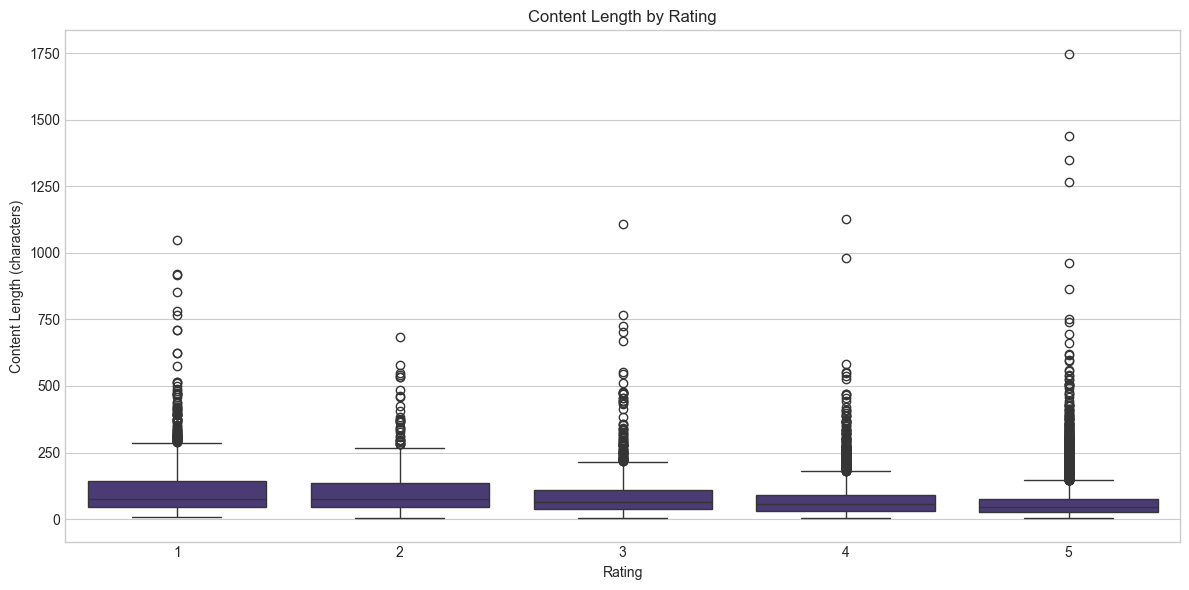

Average content length by rating:
   Rating  Average Content Length
0       1              111.600128
1       2              107.194492
2       3               93.164534
3       4               76.278404
4       5               60.257853


In [53]:
# Analyze content length by rating
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='rating',
    y=df['content'].str.len(),
    data=df
)

plt.title('Content Length by Rating')
plt.xlabel('Rating')
plt.ylabel('Content Length (characters)')
plt.tight_layout()
plt.show()


# Calculate average content length by rating
avg_length_by_rating = df.groupby('rating')['content'] \
    .apply(lambda x: x.str.len().mean()) \
    .reset_index()

avg_length_by_rating.columns = ['Rating', 'Average Content Length']

print("Average content length by rating:")
print(avg_length_by_rating.sort_values('Rating'))

In [54]:
df.shape

(21265, 6)

## 15. Save Cleaned Dataset

In [56]:
import os

output_path = r"C:/Users/HOAI HUE/Desktop/tiki/data/processed/1_cleaned_reviews.csv"

# Tạo thư mục nếu chưa tồn tại
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Lưu file
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"Cleaned data saved with {df.shape[0]} rows and {df.shape[1]} columns.")

Cleaned data saved with 21265 rows and 6 columns.


## 16. Tóm tắt quy trình làm sạch dữ liệu

1. **Bộ dữ liệu ban đầu**: Tải dữ liệu thô
2. **Giá trị thiếu**: Loại bỏ các hàng có giá trị thiếu
3. **Trùng lặp**: Loại bỏ các hàng trùng lặp
4. **Làm sạch văn bản**:
- Loại bỏ khoảng trắng thừa, xuống dòng và ký tự trở về đầu dòng
- Loại bỏ biểu tượng cảm xúc và chuẩn hóa các ký tự lặp lại
- Loại bỏ các mục chỉ có một từ và nội dung trống
5. **Bộ dữ liệu cuối cùng**: Lưu bộ dữ liệu đã được làm sạch 
